In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,auc
import matplotlib.pyplot as plt

<font color="yellow">PREPROCESSING DATA</font>

In [19]:
data=pd.read_csv(""C:/Users/swamy/ML/Class/waterQuality1.csv"")
data.head(5)

,Sample_Id,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,Usage
0,1,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,Domestic
1,2,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,Domestic
2,3,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,Agriculture
3,4,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,Domestic
4,5,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,Domestic


In [20]:
for column in data.columns.drop(['Usage']):
  data[column]=data[column].fillna(data[column].median())
print(data.isnull().sum())
label_encoder={}
for column in data.columns:
  le=LabelEncoder()
  data[column]=le.fit_transform(data[column])
  label_encoder[column]=le

Sample_Id      0
aluminium      0
ammonia        0
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
Usage          0
dtype: int64


<font color="yellow">TRANING AND TESTING DATA</font>

In [21]:
X=data.drop(['Usage'],axis=1)
y=data['Usage']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

<font color="yellow">IMPLEMENTING MODEL</font>

In [22]:
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

C:\Users\swamy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<font color="yellow"> LOGISTIC REGRRESSION METRICS</font>

In [23]:
accuracy=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred,target_names=label_encoder['Usage'].classes_)
print(f"accuracy:{accuracy}")
print("Confusion Matrix")
print(cm)
print("classification Report")
print(cr)

accuracy:0.913125
Confusion Matrix
[[1382   18]
 [ 121   79]]
classification Report
              precision    recall  f1-score   support

 Agriculture       0.92      0.99      0.95      1400
    Domestic       0.81      0.40      0.53       200

    accuracy                           0.91      1600
   macro avg       0.87      0.69      0.74      1600
weighted avg       0.91      0.91      0.90      1600



In [24]:
TN,FP,FN,TP=confusion_matrix(y_test,y_pred).ravel()
specificity=TP/(TP+FN)
sensitivity=TN/(TN+FP)
print(f"specificity:{specificity}")
print(f"sensitivity:{sensitivity}")

specificity:0.395
sensitivity:0.9871428571428571


AUC: 0.8719142857142856


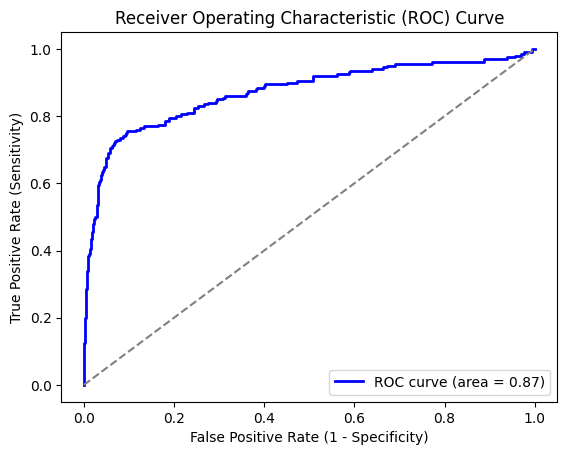

In [25]:
y_pred_proba=model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc}")

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random guess
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [26]:
from sklearn.svm import SVC
model=SVC(probability=True)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

<font color="yellow"> SVM METRICS</font>

In [27]:
accuracy=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred,target_names=label_encoder['Usage'].classes_)
print(f"accuracy:{accuracy}")
print("Confusion Matrix")
print(cm)
print("classification Report")
print(cr)

accuracy:0.94
Confusion Matrix
[[1387   13]
 [  83  117]]
classification Report
              precision    recall  f1-score   support

 Agriculture       0.94      0.99      0.97      1400
    Domestic       0.90      0.58      0.71       200

    accuracy                           0.94      1600
   macro avg       0.92      0.79      0.84      1600
weighted avg       0.94      0.94      0.93      1600



In [28]:
TN,FP,FN,TP=confusion_matrix(y_test,y_pred).ravel()
specificity=TP/(TP+FN)
sensitivity=TN/(TN+FP)
print(f"specificity:{specificity}")
print(f"sensitivity:{sensitivity}")

specificity:0.585
sensitivity:0.9907142857142858


AUC: 0.8394017857142857


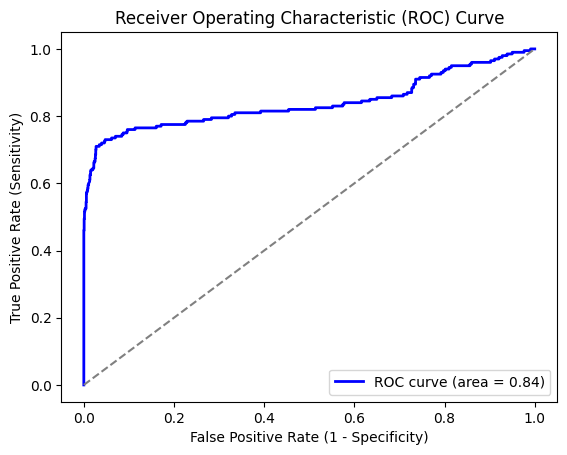

In [29]:
y_pred_proba=model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc}")

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random guess
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('R eceiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

<font color="yellow"> RANDOM FOREST CLASSIFFIER</font>

In [31]:
accuracy=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred,target_names=label_encoder['Usage'].classes_)
print(f"accuracy:{accuracy}")
print("Confusion Matrix")
print(cm)
print("classification Report")
print(cr)

accuracy:0.965625
Confusion Matrix
[[1389   11]
 [  44  156]]
classification Report
              precision    recall  f1-score   support

 Agriculture       0.97      0.99      0.98      1400
    Domestic       0.93      0.78      0.85       200

    accuracy                           0.97      1600
   macro avg       0.95      0.89      0.92      1600
weighted avg       0.96      0.97      0.96      1600



In [32]:
TN,FP,FN,TP=confusion_matrix(y_test,y_pred).ravel()
specificity=TP/(TP+FN)
sensitivity=TN/(TN+FP)
print(f"specificity:{specificity}")
print(f"sensitivity:{sensitivity}")

specificity:0.78
sensitivity:0.9921428571428571


AUC: 0.9912696428571428


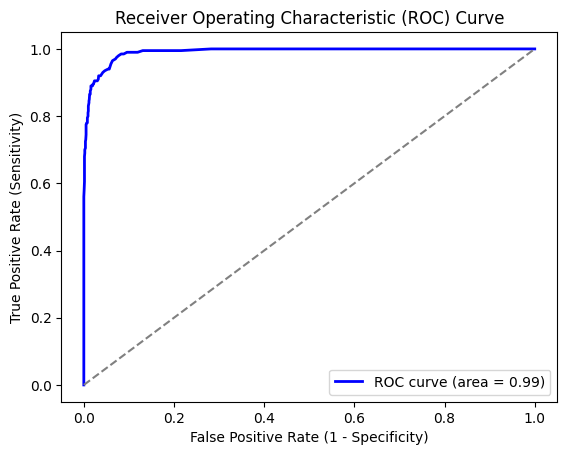

In [33]:
y_pred_proba=model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc}")

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random guess
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()